# Komunitas Facebook


In [ ]:
import networkx as nx
from community import community_louvain  # python-louvain
import matplotlib.pyplot as plt

In [ ]:
with open ('facebook_combined.txt','r') as file :
  data = file.read()
print(data)

0 1
0 2
0 3
0 4
0 5
0 6
0 7
0 8
0 9
0 10
0 11
0 12
0 13
0 14
0 15
0 16
0 17
0 18
0 19
0 20
0 21
0 22
0 23
0 24
0 25
0 26
0 27
0 28
0 29
0 30
0 31
0 32
0 33
0 34
0 35
0 36
0 37
0 38
0 39
0 40
0 41
0 42
0 43
0 44
0 45
0 46
0 47
0 48
0 49
0 50
0 51
0 52
0 53
0 54
0 55
0 56
0 57
0 58
0 59
0 60
0 61
0 62
0 63
0 64
0 65
0 66
0 67
0 68
0 69
0 70
0 71
0 72
0 73
0 74
0 75
0 76
0 77
0 78
0 79
0 80
0 81
0 82
0 83
0 84
0 85
0 86
0 87
0 88
0 89
0 90
0 91
0 92
0 93
0 94
0 95
0 96
0 97
0 98
0 99
0 100
0 101
0 102
0 103
0 104
0 105
0 106
0 107
0 108
0 109
0 110
0 111
0 112
0 113
0 114
0 115
0 116
0 117
0 118
0 119
0 120
0 121
0 122
0 123
0 124
0 125
0 126
0 127
0 128
0 129
0 130
0 131
0 132
0 133
0 134
0 135
0 136
0 137
0 138
0 139
0 140
0 141
0 142
0 143
0 144
0 145
0 146
0 147
0 148
0 149
0 150
0 151
0 152
0 153
0 154
0 155
0 156
0 157
0 158
0 159
0 160
0 161
0 162
0 163
0 164
0 165
0 166
0 167
0 168
0 169
0 170
0 171
0 172
0 173
0 174
0 175
0 176
0 177
0 178
0 179
0 180
0 181
0 182
0 183
0 184
0 18

## Hitung PageRank

In [ ]:
import networkx as nx

file_path = "facebook_combined.txt"
G = nx.read_edgelist(file_path, nodetype=int)

print("Jumlah Node :", G.number_of_nodes())
print("Jumlah Edge :", G.number_of_edges())

# =======================
#  PAGE RANK SELURUH GRAF
# =======================
pr = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1.0e-06)
# pr adalah dict: {node: skor_pagerank}


Jumlah Node : 4039
Jumlah Edge : 88234


## Display Network

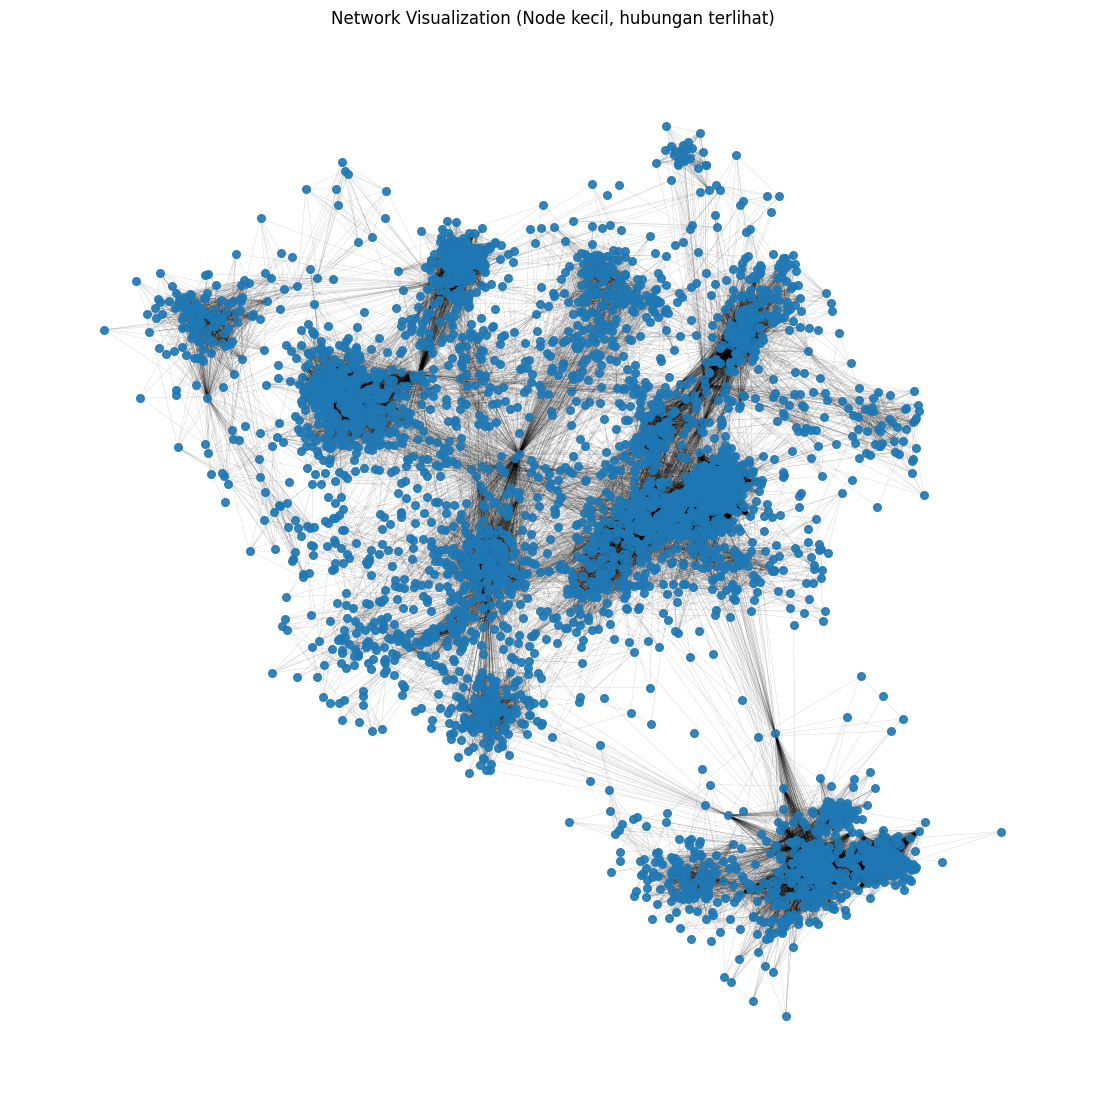

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

file_path = "facebook_combined.txt"
G = nx.read_edgelist(file_path, nodetype=int)

# layout untuk tampilan rapi
pos = nx.spring_layout(G, k=0.15, iterations=40)

plt.figure(figsize=(14, 14))

# node kecil
nx.draw_networkx_nodes(G, pos,
                       node_size=30,
                       node_color="#1f78b4",
                       alpha=0.9)

# edge tipis agar tidak terlalu gelap
nx.draw_networkx_edges(G, pos,
                       width=0.2,
                       alpha=0.25)

plt.title("Network Visualization (Node kecil, hubungan terlihat)")
plt.axis("off")
plt.show()


## Hitung Jumlah komunitas

In [ ]:
file_path = "facebook_combined.txt"

komunitas = []   # list of (node_kiri, [tetangga_kanan])

with open(file_path, "r") as f:
    prev_left = None
    neighbors = []

    for line in f:
        if not line.strip():
            continue
        left, right = map(int, line.split())

        if prev_left is None:
            prev_left = left

        if left == prev_left:
            neighbors.append(right)
        else:
            komunitas.append((prev_left, neighbors))
            prev_left = left
            neighbors = [right]

    if prev_left is not None:
        komunitas.append((prev_left, neighbors))

print("Jumlah komunitas (berdasar kolom kiri):", len(komunitas))

# contoh: print 5 komunitas pertama, semua tetangga
for i, (node_kiri, tetangga) in enumerate(komunitas[:5], start=1):
    print(f"Komunitas {i}: node {node_kiri} -> {tetangga}")


Jumlah komunitas (berdasar kolom kiri): 3663
Komunitas 1: node 0 -> [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208,

## Kasih warna Tiap Komunitas

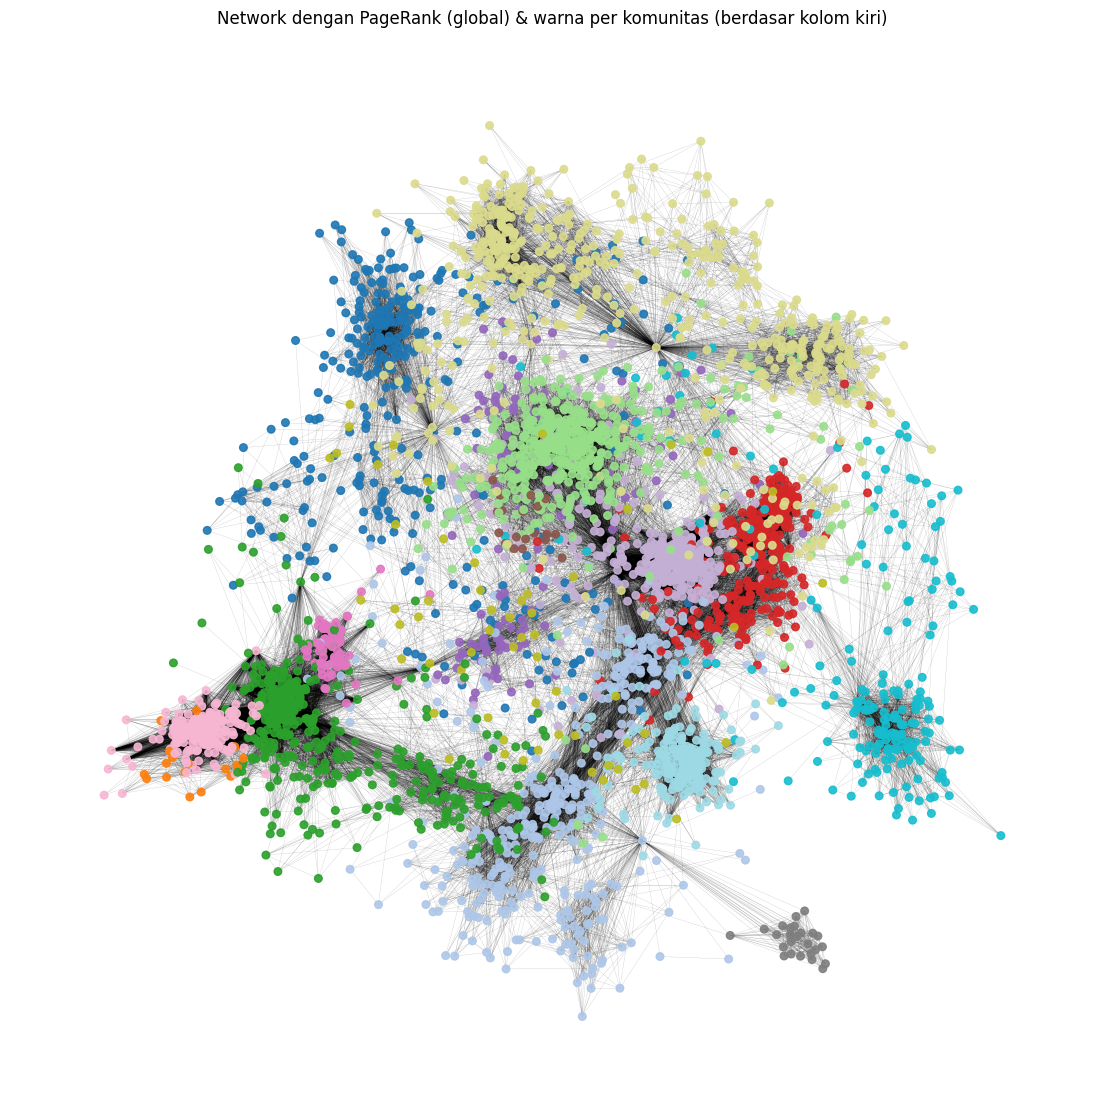

In [ ]:
partition = community_louvain.best_partition(G)
comm_index = [partition[node] for node in G.nodes()]

# 5. Layout dan gambar: node kecil, warna per komunitas
pos = nx.spring_layout(G, k=0.15, iterations=40)

plt.figure(figsize=(14, 14))

nx.draw_networkx_nodes(
    G, pos,
    node_size=30,              # kecil-kecil
    node_color=comm_index,     # warna berdasarkan komunitas
    cmap=plt.cm.tab20,         # palet warna (akan muter kalau komunitasnya banyak)
    alpha=0.9
)

nx.draw_networkx_edges(
    G, pos,
    width=0.2,
    alpha=0.25
)

plt.axis("off")
plt.title("Network dengan PageRank (global) & warna per komunitas (berdasar kolom kiri)")
plt.show()